In [1]:
#load required libraries
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

#load data
print("Reading data...")
adata = sc.read_h5ad("../Data/Final.h5ad")
adata

Reading data...


AnnData object with n_obs × n_vars = 92942 × 23249
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'percent.mt', 'percent.hbb', 'percent.hba', 'nCount_SCT', 'nFeature_SCT', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'total_counts', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts'

normalizing counts per cell
    finished (0:00:05)


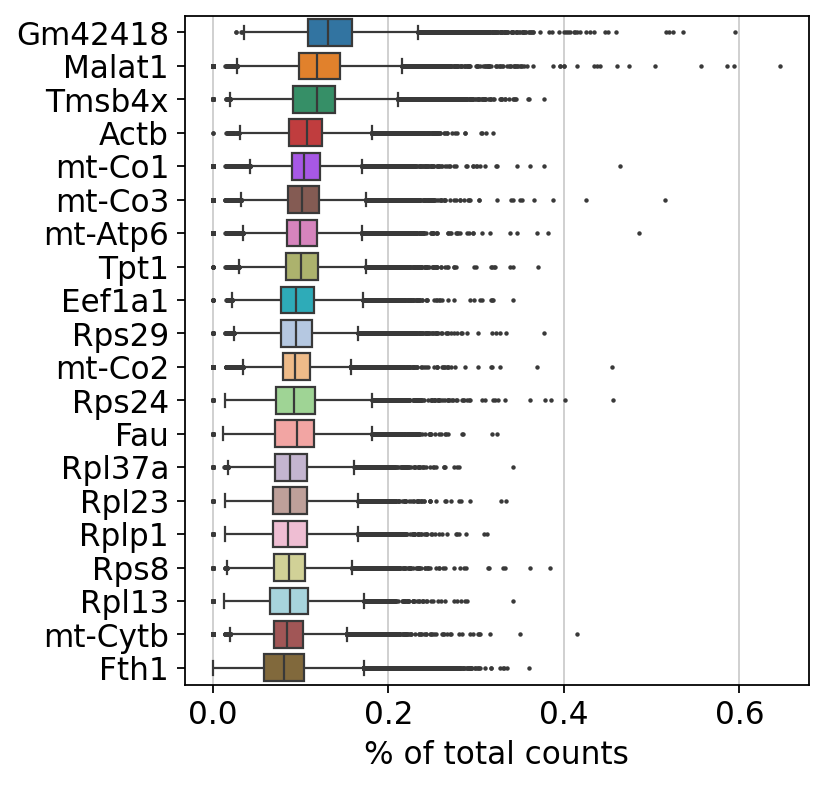

In [2]:
sc.pl.highest_expr_genes(adata, n_top=20)

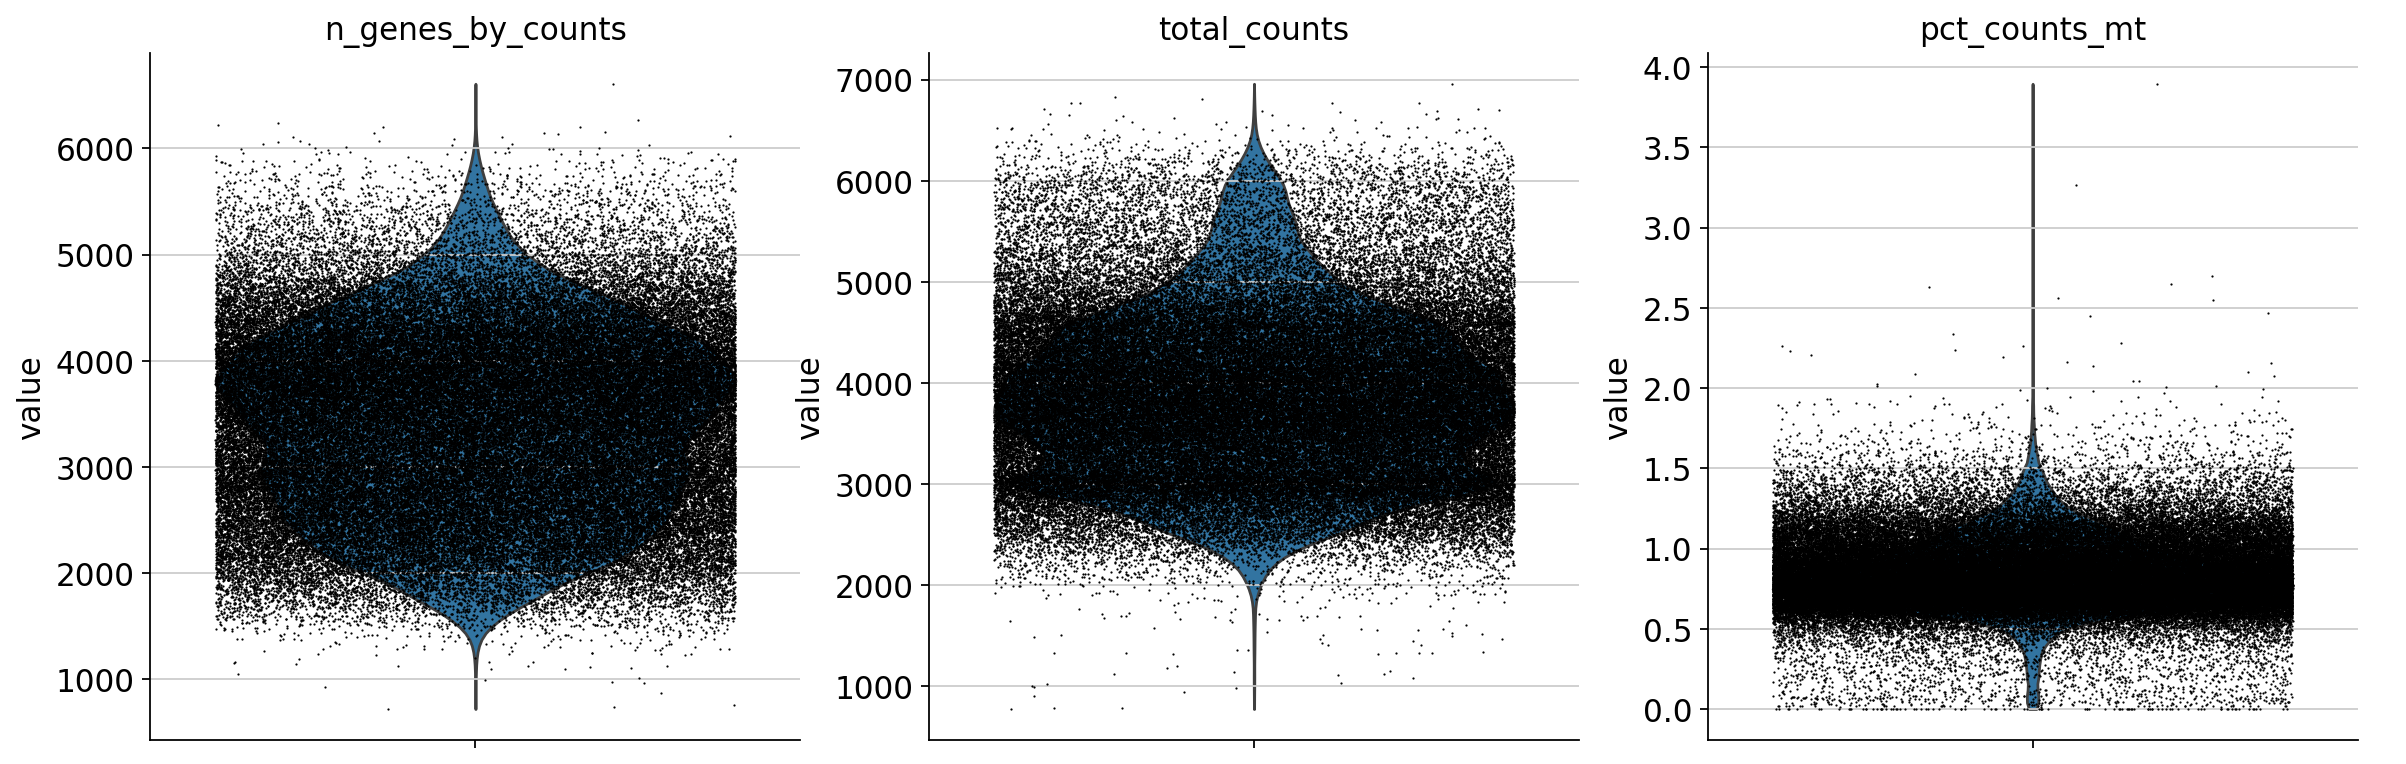

In [3]:
# annotate mitochondrial genes as 'mt' and calculate qc metrics
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
# plot a violin plot with some QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],jitter=0.4, multi_panel=True)

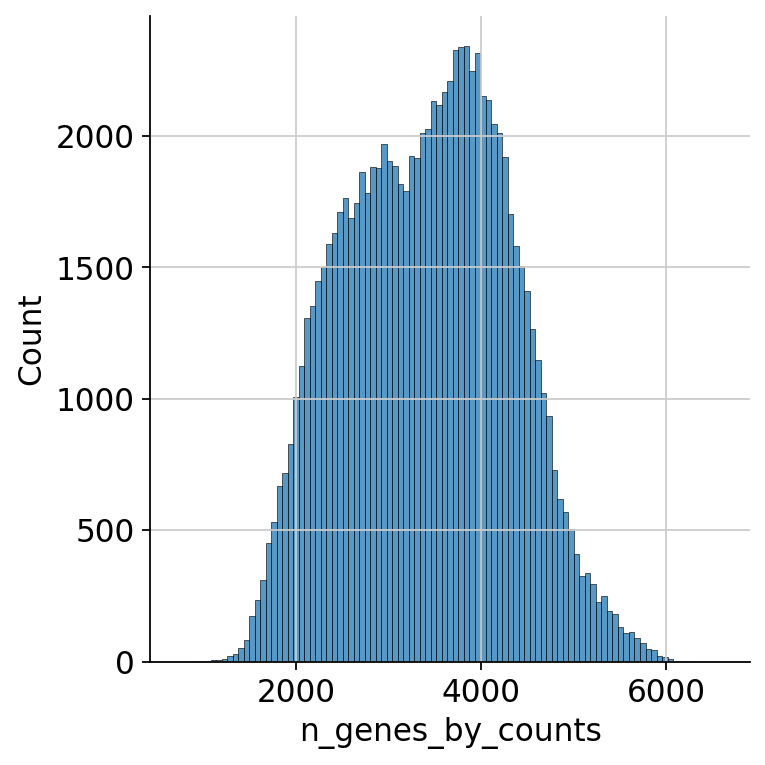

In [4]:
# plot a histograph of a single variable
sns.displot(adata.obs["n_genes_by_counts"])

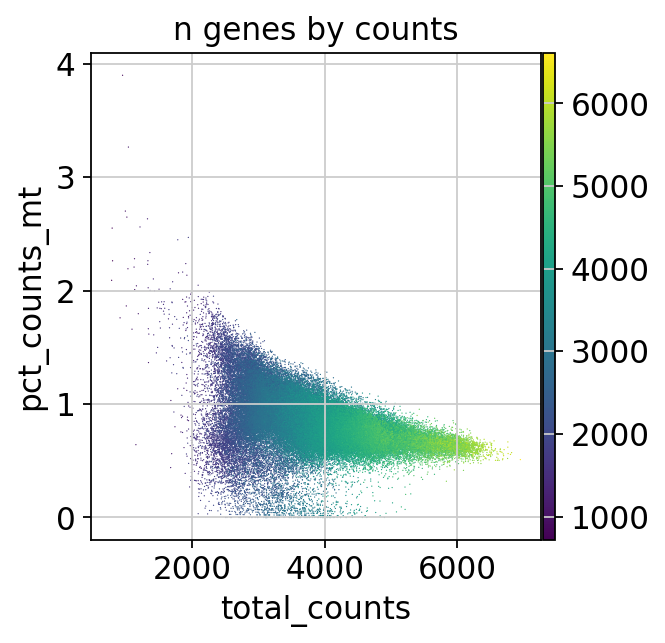

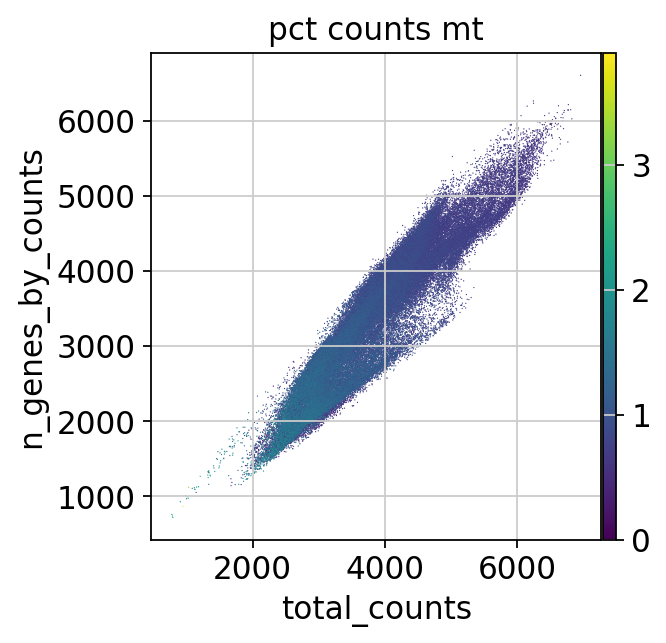

In [5]:
# plot a scatter plot of QC metrics
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', color = 'n_genes_by_counts')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color = 'pct_counts_mt')

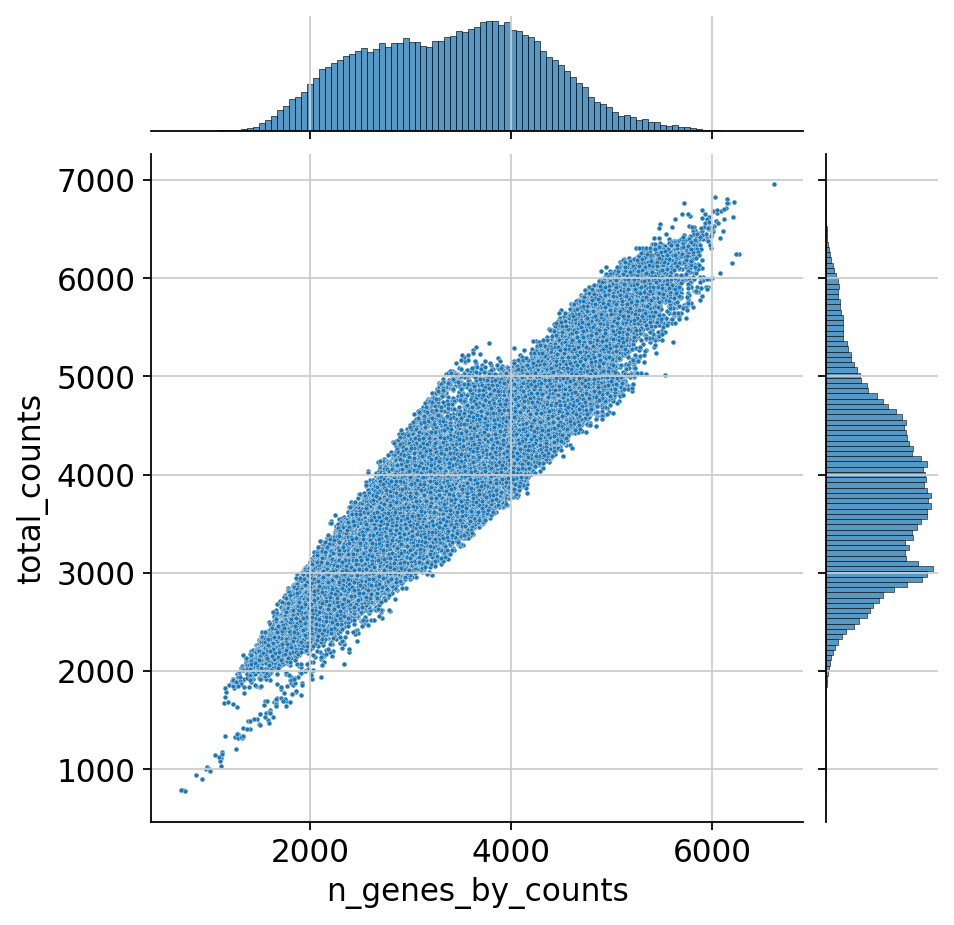

In [6]:
sns.jointplot(
    x="n_genes_by_counts",
    y="total_counts",
    data=adata.obs,
    kind="scatter",
    s=5
)

In [7]:
mito_gene_names = adata.var_names[adata.var['mt']]
print(f"Number of mitochondrial genes: {len(mito_gene_names)}")
print(mito_gene_names)
mito_adata = adata[:, mito_gene_names]
mito_counts = adata[:, adata.var['mt']].X.sum(axis=0)
mito_gene_counts = sorted(zip(mito_counts, adata.var_names[adata.var['mt']]), reverse=True)
print("Top 10 expressed mitochondrial genes:")
for count, gene in mito_gene_counts:
    print(f"{gene}: {count}")

Number of mitochondrial genes: 13
Index(['mt-Nd1', 'mt-Nd2', 'mt-Co1', 'mt-Co2', 'mt-Atp8', 'mt-Atp6', 'mt-Co3',
       'mt-Nd3', 'mt-Nd4l', 'mt-Nd4', 'mt-Nd5', 'mt-Nd6', 'mt-Cytb'],
      dtype='object')
Top 10 expressed mitochondrial genes:
mt-Nd1: [[254179.7807135  247889.09059799 371877.51863139 334455.9187772
   52075.99670229 357592.87661994 361394.79060255 135460.23811684
   90403.91496002 263071.27395574 137310.33570071  20700.87727593
  301594.17440075]]


In [8]:
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize
sc.pp.log1p(adata)  # Log transform

normalizing counts per cell
    finished (0:00:04)


In [9]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5) # Feature selection
adata = adata[:, adata.var.highly_variable] # filter to variable genes.
adata

extracting highly variable genes
    finished (0:00:08)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


View of AnnData object with n_obs × n_vars = 92942 × 3392
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'percent.mt', 'percent.hbb', 'percent.hba', 'nCount_SCT', 'nFeature_SCT', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'total_counts', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [10]:
sc.pp.scale(adata, max_value=10) # Scale
sc.tl.pca(adata, svd_solver='arpack') # PCA

/home/gupta385/.local/lib/python3.12/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:02:10)


In [11]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40) # Adjust n_neighbors and n_pcs as needed
sc.tl.leiden(adata, resolution=1.0)

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:42)
running Leiden clustering


/tmp/ipykernel_1264975/3283933795.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1.0)


    finished: found 56 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:08)


In [26]:
sc.tl.leiden(adata, resolution=0.083)

running Leiden clustering
    finished: found 17 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:13)


In [30]:
import numpy as np

In [31]:
cluster_names = np.array(["Endothlial (1)", "T-cell", "Macrophages", "Kupffer", "B-cells", "Hepatocytes", "DC (1)", "Endothelial (2)", "NK", "DC (2)", "Neutrophils", "Endothelial (3)", "pDC", "Cholangiocyte", "Basophil", "Stellate", "Immature B-cell"])

# Rename the categories in the 'leiden' observation
adata.rename_categories('leiden', cluster_names)

# Optional: verify the renaming
print(adata.obs['leiden'].cat.categories)

# Or, if you want to create a new column with the names, instead of renaming the categories of the leiden column:
# adata.obs['cell_type'] = adata.obs['leiden'].cat.rename_categories(cluster_names)

# #verify your new column.
# print(adata.obs['cell_type'].cat.categories)

Index(['Endothlial (1)', 'T-cell', 'Macrophages', 'Kupffer', 'B-cells',
       'Hepatocytes', 'DC (1)', 'Endothelial (2)', 'NK', 'DC (2)',
       'Neutrophils', 'Endothelial (3)', 'pDC', 'Cholangiocyte', 'Basophil',
       'Stellate', 'Immature B-cell'],
      dtype='object')


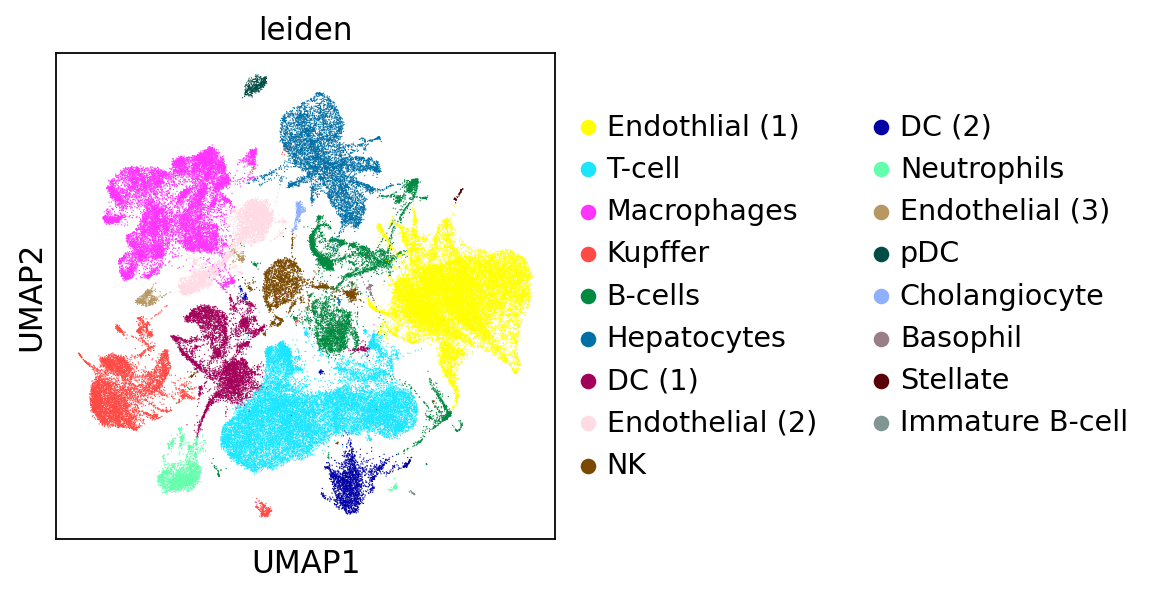

In [32]:
sc.pl.umap(adata, color=['leiden'])

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:02:40)


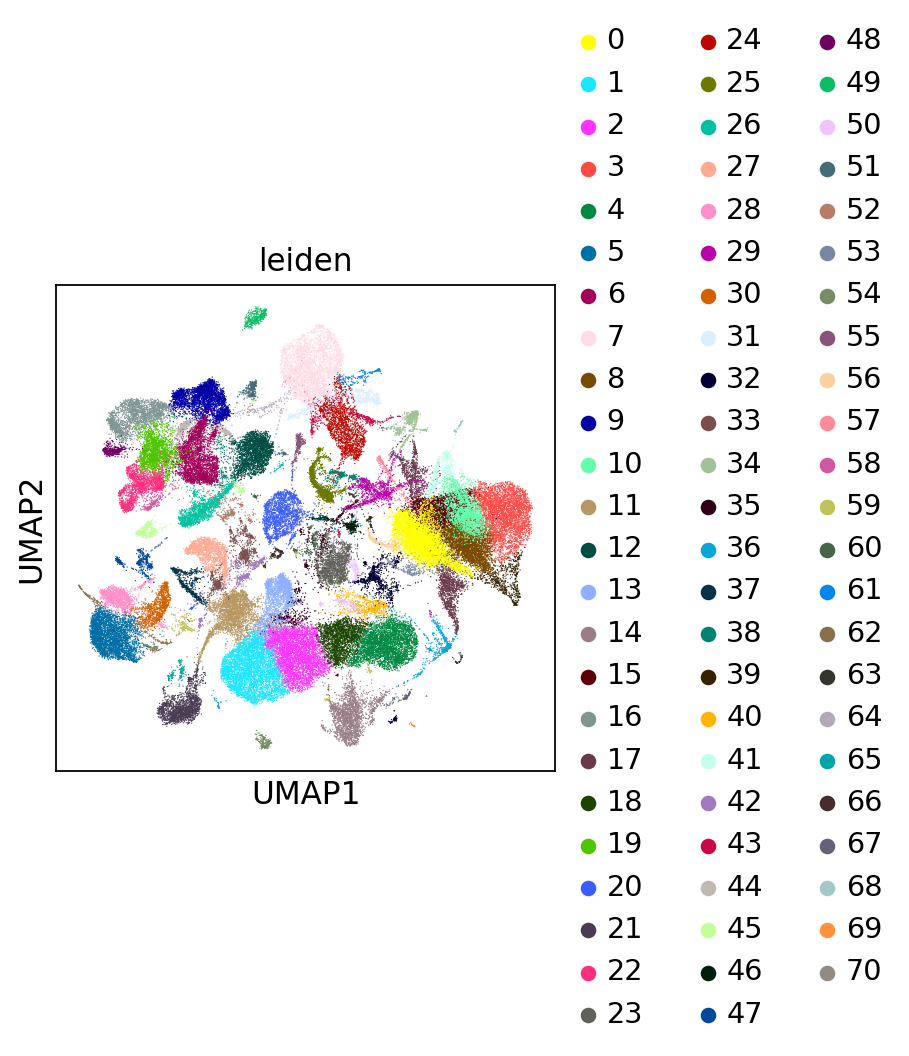

In [13]:
sc.tl.umap(adata) # or sc.tl.tsne(adata)
sc.pl.umap(adata, color=['leiden']) # or sc.pl.tsne(adata, color=['leiden'])

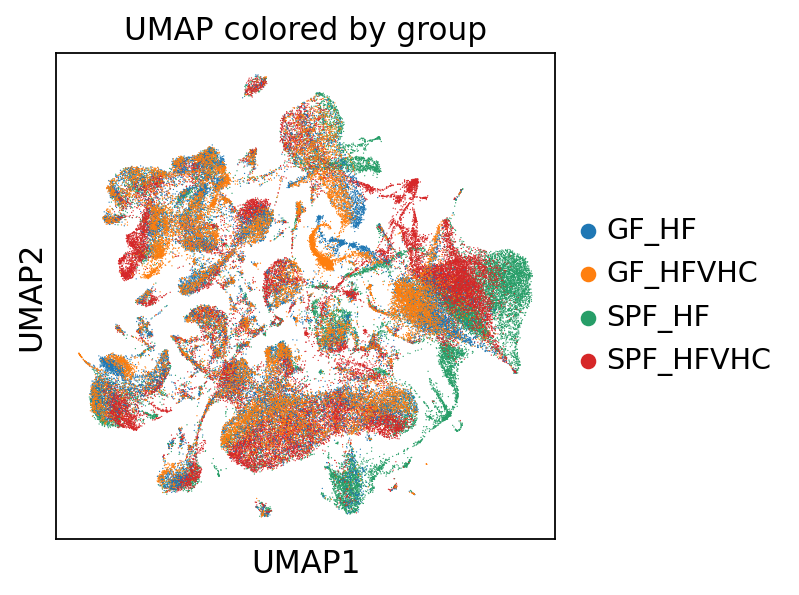

In [24]:
sc.pl.umap(adata, color='group', title='UMAP colored by group')

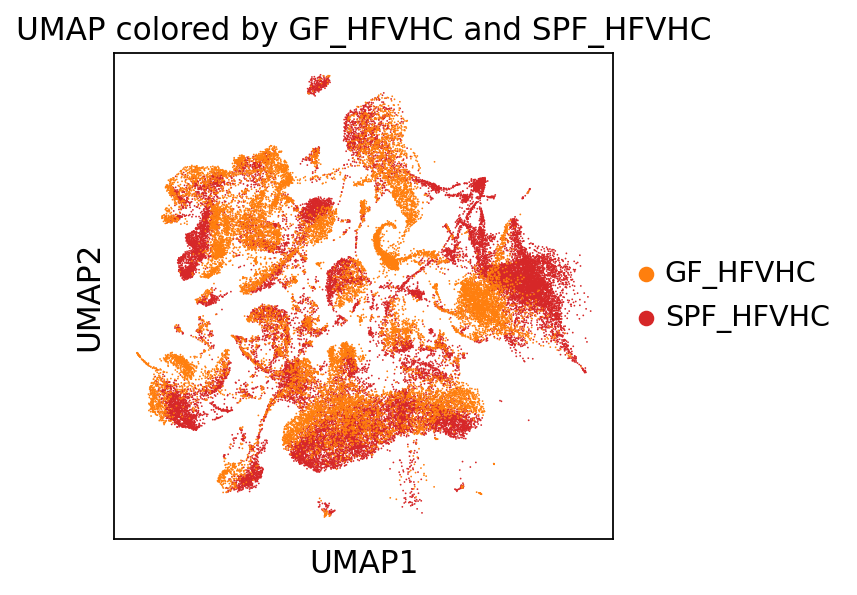

In [27]:
mask = adata.obs['group'].isin(['GF_HFVHC', 'SPF_HFVHC'])
adata_subset = adata[mask]

# Plot the subset
sc.pl.umap(adata_subset, color='group', title='UMAP colored by GF_HFVHC and SPF_HFVHC')

In [34]:
adata.obs['leiden']

0        29
1         6
2        17
3         0
4         6
         ..
92937    12
92938    10
92939    26
92940    10
92941     5
Name: leiden, Length: 92942, dtype: category
Categories (56, object): ['0', '1', '2', '3', ..., '52', '53', '54', '55']

In [35]:
x = ["Endothlial (1)", "T-cell", "Macrophages", "Kupffer", "B-cells", "Hepatocytes", "DC (1)", "Endothelial (2)", "NK", "DC (2)", "Neutrophils", "Endothelial (3)", "pDC", "Cholangiocyte", "Basophil", "Stellate", "Immature B-cell"]
len(x)

17

In [29]:
import anndata
import celltypist

In [32]:
# Annotate with CellTypist
predictions = celltypist.annotate(adata, model='Immune_Cells.pkl')

# Add annotations to adata.obs
adata.obs = adata.obs.join(predictions.predicted_labels)

# View the results
adata.obs['predicted_labels']

FileNotFoundError: 🛑 No such file: Immune_Cells.pkl

In [ ]:
# Visualize (optional)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color='predicted_labels', title='UMAP colored by CellTypist predictions')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:44)


/home/gupta385/.local/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/gupta385/.local/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/gupta385/.local/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/gupta385/.local/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


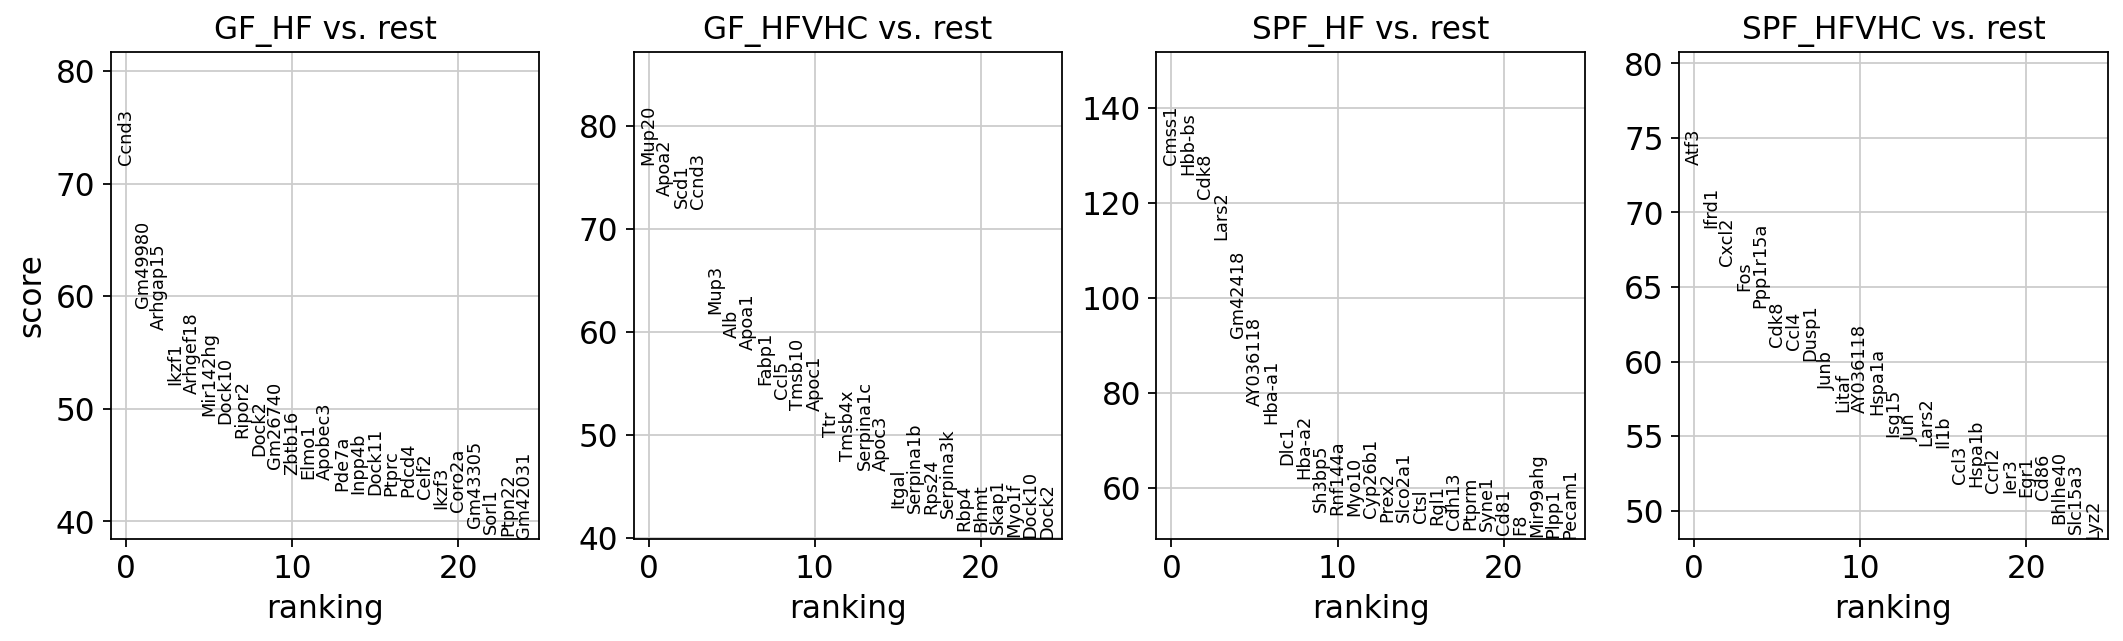

In [14]:
sc.tl.rank_genes_groups(adata, 'group', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [15]:
results = adata.uns['rank_genes_groups']

# Print the results for each group
for group in results['names'].dtype.names:
    print(f"Group: {group}")
    genes = pd.DataFrame({
        'gene': results['names'][group],
        'scores': results['scores'][group],
        'pvals': results['pvals'][group],
        'pvals_adj': results['pvals_adj'][group],
        'logfoldchanges': results['logfoldchanges'][group]
    })
    print(genes)
    print("\n" + "-" * 40 + "\n") #add a seperator.

Group: GF_HF
          gene     scores  pvals  pvals_adj  logfoldchanges
0        Ccnd3  71.714561    0.0        0.0             NaN
1      Gm49980  59.010166    0.0        0.0             NaN
2     Arhgap15  57.059319    0.0        0.0             NaN
3        Ikzf1  52.105511    0.0        0.0             NaN
4     Arhgef18  51.353901    0.0        0.0             NaN
...        ...        ...    ...        ...             ...
3387  AY036118 -70.468964    0.0        0.0             NaN
3388   Gm42418 -82.234573    0.0        0.0             NaN
3389     Cmss1 -83.525497    0.0        0.0             NaN
3390      Cdk8 -96.836609    0.0        0.0             NaN
3391     Lars2 -97.919777    0.0        0.0             NaN

[3392 rows x 5 columns]

----------------------------------------

Group: GF_HFVHC
          gene      scores  pvals  pvals_adj  logfoldchanges
0        Mup20   76.264542    0.0        0.0             NaN
1        Apoa2   73.227669    0.0        0.0             NaN


In [16]:
top_n = 1650  # You can adjust this

# Dictionary to store top genes for each group
top_genes = {}

# Extract top genes for each group
for group in results['names'].dtype.names:
    top_genes[group] = set(results['names'][group][:top_n])

# print(top_genes)

# Find common genes
common_genes = set.intersection(*top_genes.values())

# Print common genes
print("Common Genes Across All Groups:")
print(common_genes)

Common Genes Across All Groups:
{'Ptprd', 'Ddo', 'Cgn', 'Ctf1', 'Gm42067'}


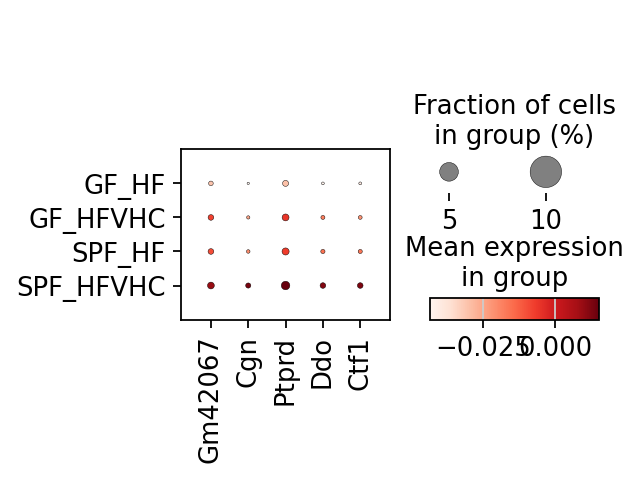

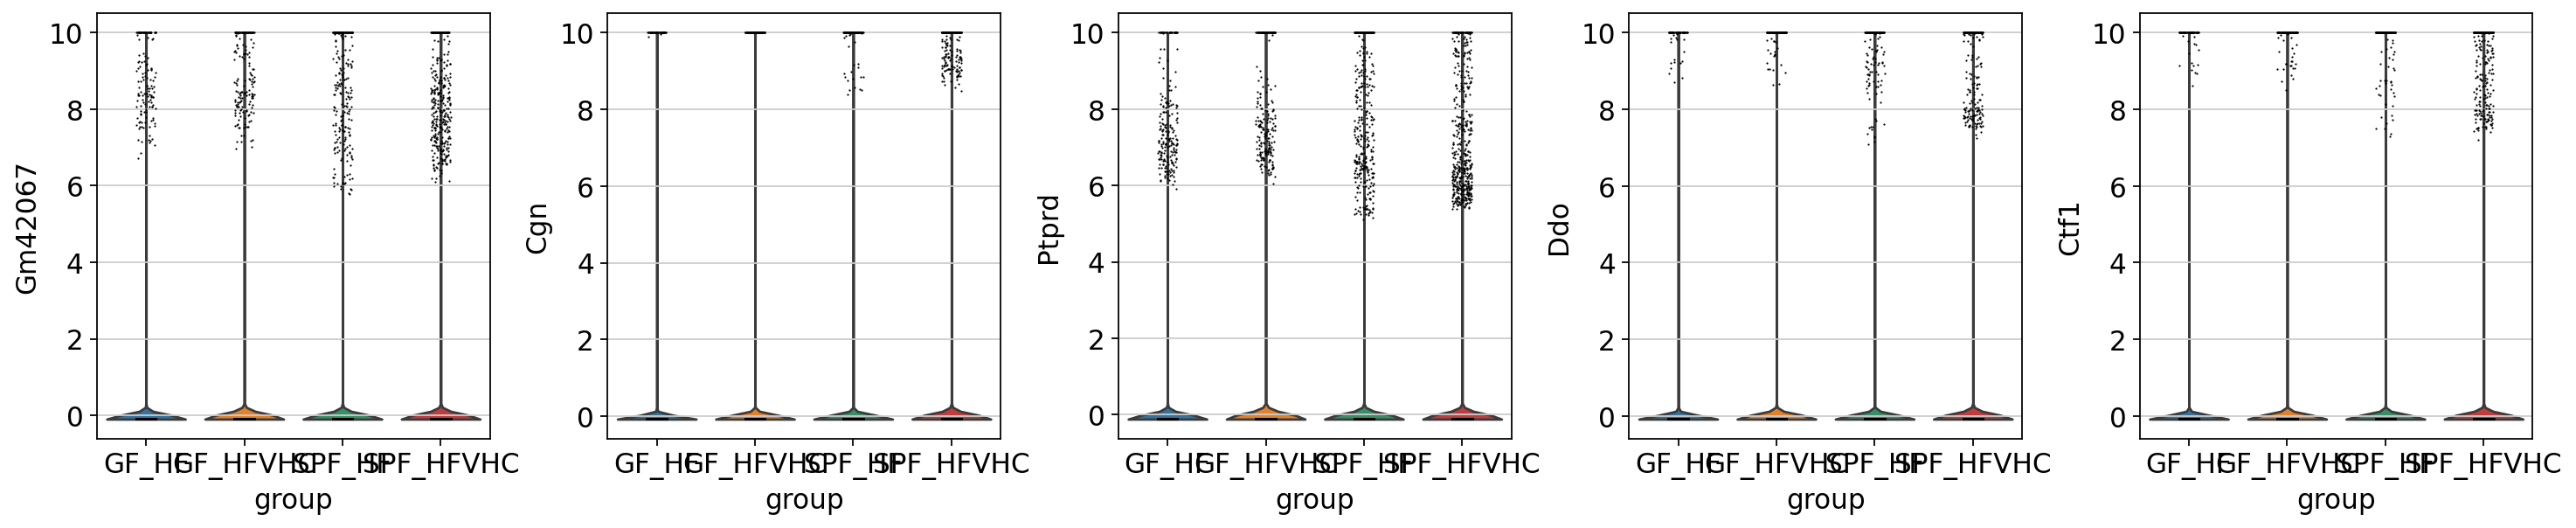

In [17]:
marker_genes = ['Gm42067', 'Cgn', 'Ptprd', 'Ddo', 'Ctf1',]  # Replace with your marker genes
sc.pl.dotplot(adata, marker_genes, groupby='group')
sc.pl.violin(adata, marker_genes, groupby='group')

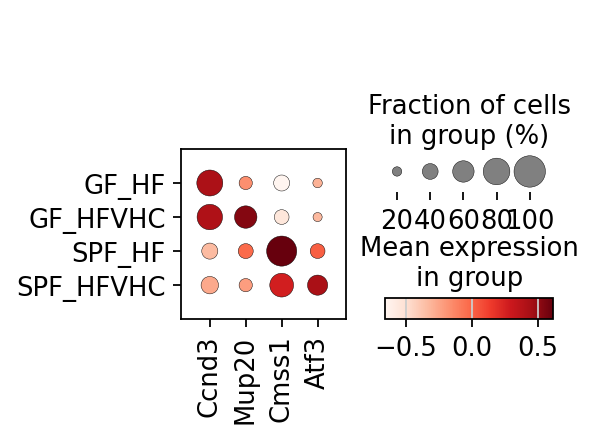

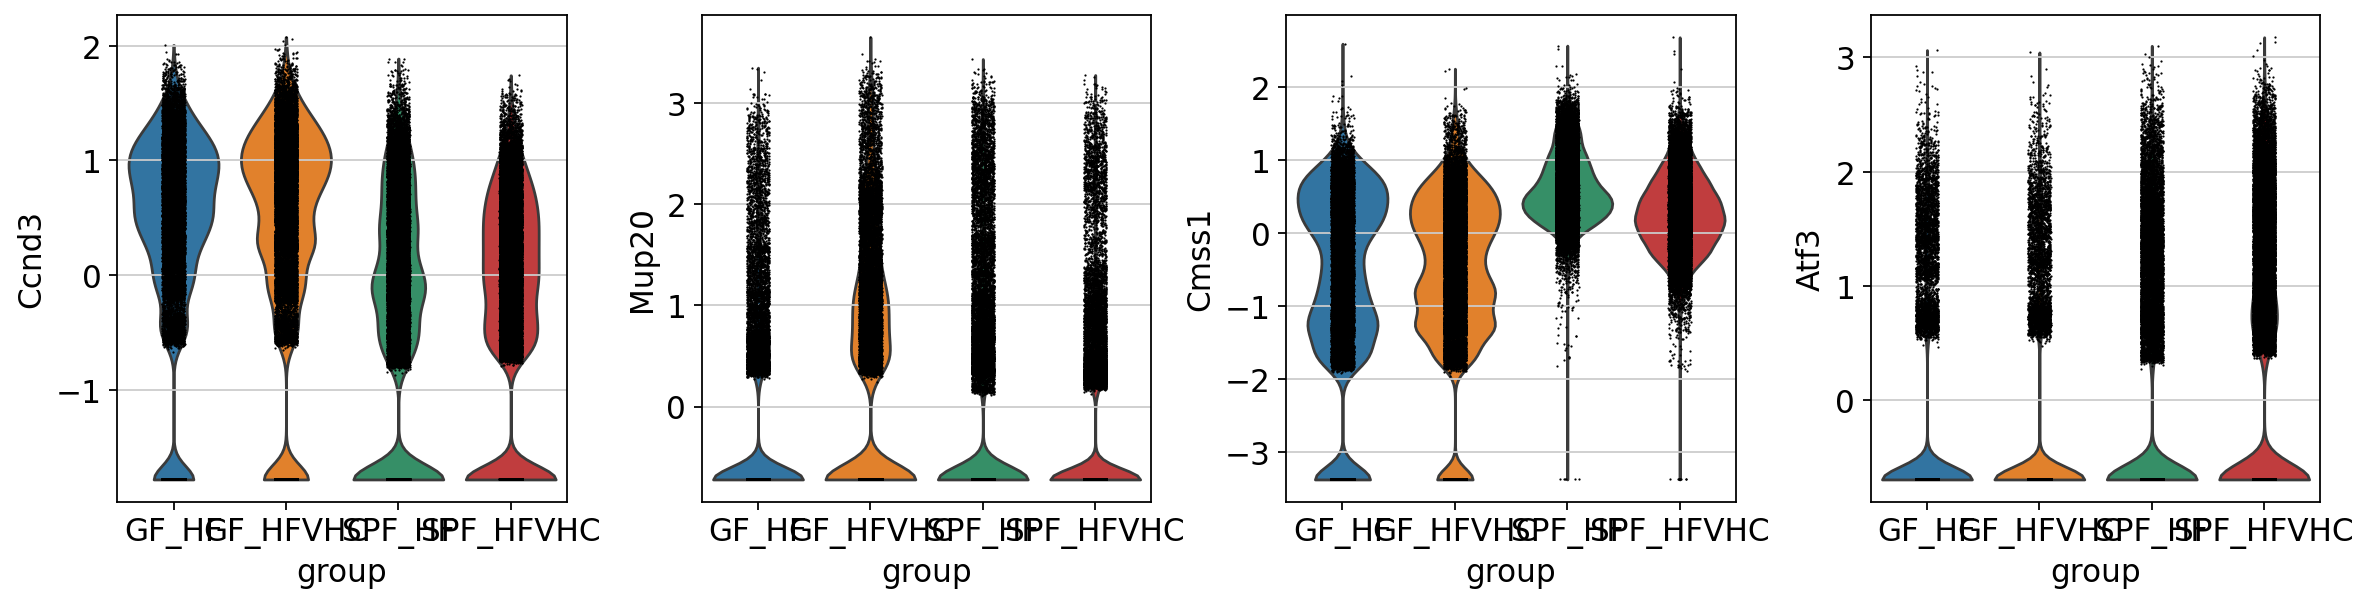

In [18]:
marker_genes = ['Ccnd3', 'Mup20','Cmss1', 'Atf3']  # Replace with your marker genes
sc.pl.dotplot(adata, marker_genes, groupby='group')
sc.pl.violin(adata, marker_genes, groupby='group')

In [19]:
adata.write("../Data/Processed.h5ad")